dataset: https://www.kaggle.com/datasets/aliiihussain/car-price-prediction?resource=download


Steps: for a ML project:

Dataset Overview
Datatype conversion

EDA Visualizations

Correlation Analysis

Regression/Classification Model

Model Evaluation

Business Interpretation

Limitations & Improvements

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load Dataset & datset summary


In [ ]:
df = pd.read_csv("/content/car_price_prediction_.csv")
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [ ]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


### How to find unique values of Brand?

How to print only "Toyota" brand car details from the dataset

In [ ]:
# df['Brand'].unique()

In [ ]:
# df['Condition'].unique()

In [ ]:
df[df['Brand'] == 'Audi']

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
5,6,Audi,2019,2.4,Diesel,Automatic,246553,Like New,88969.76,Q7
6,7,Audi,2020,4.0,Electric,Automatic,135486,Used,63498.75,Q5
13,14,Audi,2023,5.4,Electric,Automatic,263894,Like New,70193.74,Q7
17,18,Audi,2022,4.4,Hybrid,Automatic,192803,Like New,75044.95,A3
...,...,...,...,...,...,...,...,...,...,...
2487,2488,Audi,2021,4.6,Electric,Automatic,9466,Used,15126.76,A3
2490,2491,Audi,2018,2.4,Hybrid,Manual,146539,Used,98434.45,Q5
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3


# 2. Basic Cleaning steps

In [ ]:
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [ ]:
# df.dropna(inplace=True)

# 3. Convert Categorical Columns

In [ ]:
le = LabelEncoder()

for col in ["Brand", "Model", "Fuel Type", "Transmission"]:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,5,2016,2.3,3,1,114832,New,26613.92,19
1,2,1,2018,4.4,1,1,143190,Used,14679.61,1
2,3,0,2013,4.5,1,1,181601,New,44402.61,3
3,4,5,2011,4.1,0,0,68682,New,86374.33,20
4,5,2,2009,2.6,0,1,223009,Like New,73577.10,21


# 4. Exploratory Data Analysis

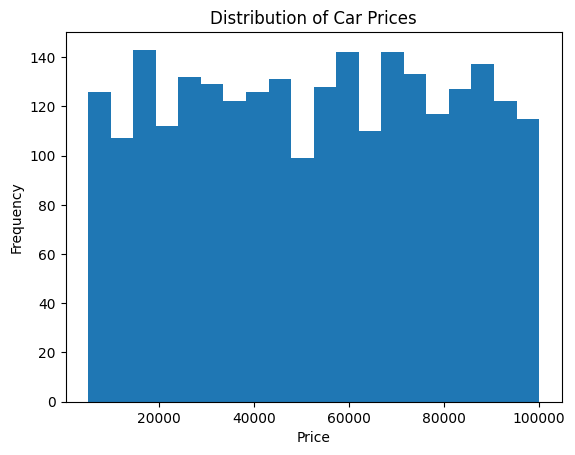

In [ ]:
#Univariate EDA
plt.hist(df["Price"], bins=20)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

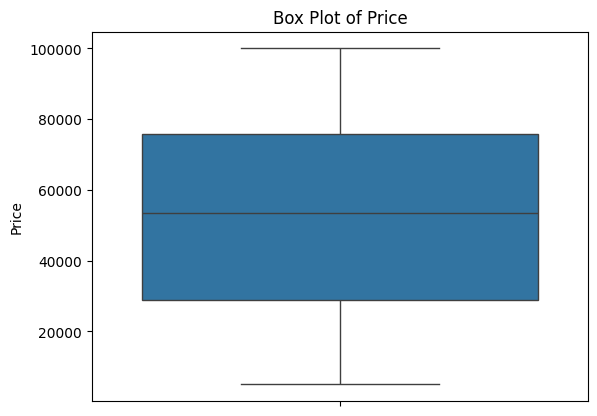

In [ ]:
sns.boxplot(y=df["Price"])
plt.title("Box Plot of Price")
plt.show() #outliers

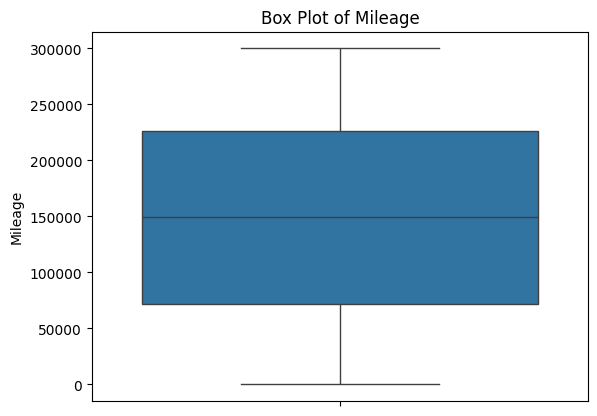

In [ ]:
sns.boxplot(y=df["Mileage"])
plt.title("Box Plot of Mileage")
plt.show()

Relationship Analysis (Bivariate EDA)

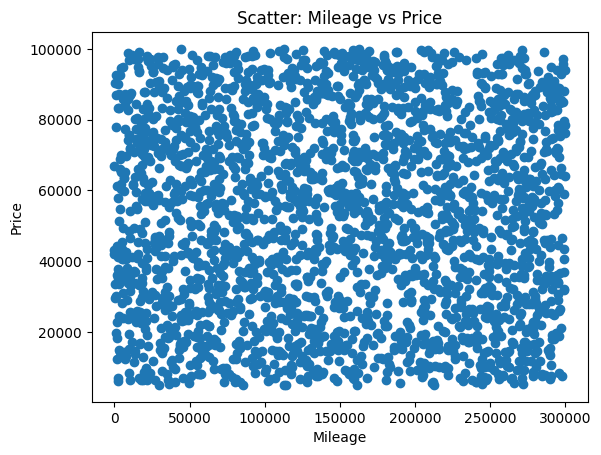

In [ ]:
plt.scatter(df["Mileage"], df["Price"])
plt.title("Scatter: Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

# 5. Categorical Analysis

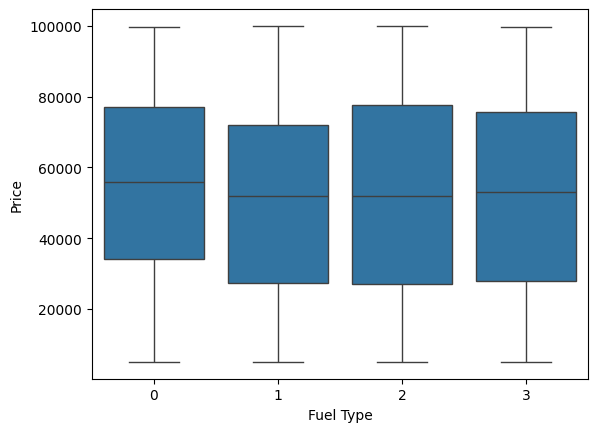

In [ ]:
sns.boxplot(x="Fuel Type", y="Price", data=df)
plt.show()

# 6. Correlation Analysis

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

ValueError: could not convert string to float: 'New'

In [ ]:
df['Condition'].unique()

array(['New', 'Used', 'Like New'], dtype=object)

In [ ]:
le1 = LabelEncoder()

df['Condition'] = le1.fit_transform(df['Condition'])

In [ ]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [ ]:
df.drop(columns=['Car ID'], inplace=True)

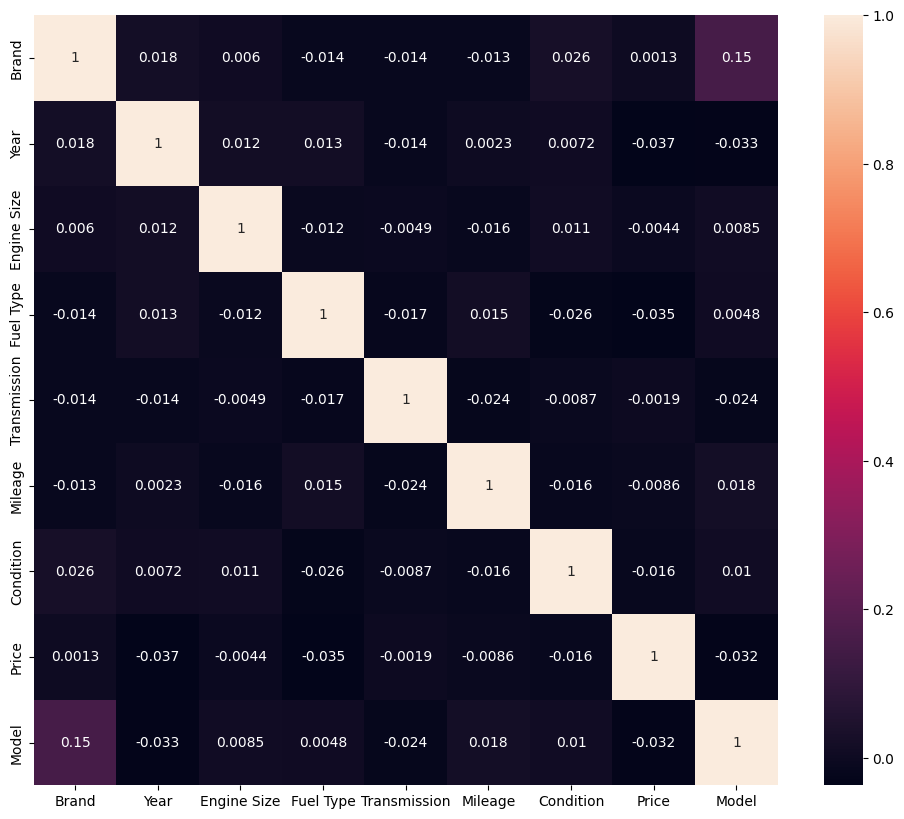

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, ax=ax)
plt.show()

In [ ]:
# plt.figure(figsize=(8,6))
# sns.heatmap(df.corr(), annot=True)
# plt.show()

# 7. Build Regression Model

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 8. Evaluate Model

In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))